In [1]:
import pandas as pd
import sys
sys.path.append('./src')
from data import data
from analysis import correlation, avrg_correlation, run_pca, regression
from plotting import plot_corr, plot_pca, plot_pca2, plot_pca3, plot_pca4, plot_pca5

## Data Preparation

We start by collecting daily closing prices for the BIST-30 constituents over the last year.
To ensure comparability across assets, we work with **logarithmic returns** instead of prices.

Log returns are preferred because:
- They are time-additive.
- They stabilize variance.
- They better capture relative price changes across assets with different price levels.

In [ ]:
prices, log_data = data()
prices.head()

/Users/mehmedekinelitog/Desktop/bist-correlation-pca/src/data.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2025-01-31")["Close"]
[*********************100%***********************]  30 of 30 completed



=== Missing Data Summary ===
Total observations per stock: 1273

Stocks with missing data:
Ticker
AKBNK    0.078555
ALARK    0.078555
YKBNK    0.078555
VAKBN    0.078555
TUPRS    0.078555
TOASO    0.078555
THYAO    0.078555
TCELL    0.078555
TAVHL    0.078555
SISE     0.078555
SAHOL    0.078555
PETKM    0.078555
ODAS     0.078555
KRDMD    0.078555
KOZAL    0.078555
KCHOL    0.078555
ISCTR    0.078555
HEKTS    0.078555
GUBRF    0.078555
GARAN    0.078555
ENKAI    0.078555
EKGYO    0.078555
BIMAS    0.078555
ASELS    0.078555
ARCLK    0.078555
ZOREN    0.078555
dtype: float64


/Users/mehmedekinelitog/Desktop/bist-correlation-pca/src/data.py:36: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Ticker,AKBNK,ALARK,ARCLK,ASELS,BIMAS,EKGYO,ENKAI,EREGL,FROTO,GARAN,...,SISE,TAVHL,TCELL,THYAO,TKFEN,TOASO,TUPRS,VAKBN,YKBNK,ZOREN
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,6.568622,5.457612,18.671036,5.248263,37.763371,1.326300,4.238447,3.349332,4.883594,9.249969,...,4.736391,27.275969,11.245292,14.487193,16.006393,16.305670,12.268352,5.56,2.105268,0.912127
2020-01-03,6.391960,5.320715,18.777222,5.296905,38.627190,1.290695,4.218672,3.297804,4.768644,8.995307,...,4.683073,26.866364,11.101121,13.940138,15.353736,16.098652,12.047904,5.37,2.046788,0.878959
2020-01-06,6.191207,5.238577,18.936502,5.369864,38.855366,1.255089,4.152755,3.264678,4.817411,8.707788,...,4.549778,26.177483,10.964960,13.256318,14.847928,15.928165,11.856213,5.16,2.005017,0.840263
2020-01-07,6.255448,5.320715,18.653337,5.452553,39.148735,1.263991,4.225264,3.286762,4.970675,8.699571,...,4.549778,27.033930,11.133158,13.227012,15.206887,16.183893,11.779535,5.25,2.005017,0.862375
2020-01-08,6.391960,5.247704,18.440966,5.418504,39.474701,1.237287,4.205489,3.283081,4.967193,9.102100,...,4.523119,26.661560,11.093111,13.187937,15.157941,16.330025,11.539921,5.36,2.021725,0.851319


## Correlation Structure of BIST-30 Stocks

Before applying PCA, we examine the average pairwise correlations across stocks.
This step is crucial because PCA is most informative when assets exhibit strong co-movement.

The results indicate:
- High correlations among bank stocks (e.g., AKBNK, GARAN, YKBNK),
- Lower correlations for more idiosyncratic stocks.

This confirms that a **common latent factor structure** likely exists,
making PCA an appropriate dimensionality reduction tool.


In [3]:
corr1,corr2 = correlation(log_data)
corr1

Ticker
GUBRF    0.404526
HEKTS    0.419270
SASA     0.436998
BIMAS    0.476212
ALARK    0.487779
ENKAI    0.489716
KOZAL    0.496054
EKGYO    0.537480
TCELL    0.542188
TKFEN    0.549501
ODAS     0.566165
ZOREN    0.566165
ASELS    0.588984
PETKM    0.598627
TUPRS    0.602721
ARCLK    0.607685
SISE     0.622659
FROTO    0.624843
TOASO    0.624843
VAKBN    0.726135
KRDMD    0.731307
EREGL    0.731307
TAVHL    0.738188
THYAO    0.738188
KCHOL    0.772733
SAHOL    0.772733
ISCTR    0.844279
GARAN    0.851782
YKBNK    0.858488
AKBNK    0.858488
dtype: float64

## Principal Component Analysis (PCA)

PCA is applied to standardized log returns to extract orthogonal factors
that explain the maximum amount of cross-sectional variance.

The figure below shows the **cumulative explained variance ratio**.
Key observations:
- The first principal component (PC1) alone explains approximately 45% of total variance.
- The first two components explain more than 53%.
- Around 6–7 components are sufficient to explain over 70% of the variance.

This suggests that BIST-30 returns are largely driven by a small number of common factors.

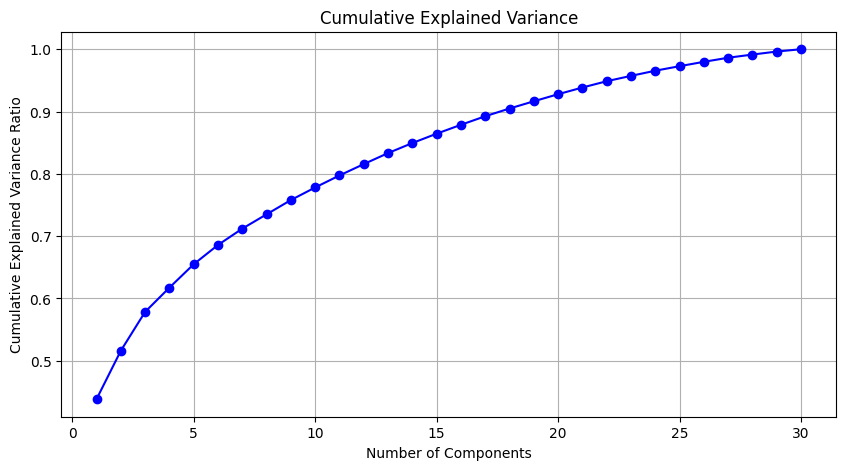

PC1: 0.438
PC2: 0.516
PC3: 0.578
PC4: 0.617
PC5: 0.655
PC6: 0.686
PC7: 0.712
PC8: 0.735
PC9: 0.758
PC10: 0.778
PC11: 0.797
PC12: 0.816
PC13: 0.833
PC14: 0.849
PC15: 0.864
PC16: 0.879
PC17: 0.892
PC18: 0.905
PC19: 0.916
PC20: 0.928
PC21: 0.939
PC22: 0.949
PC23: 0.957
PC24: 0.965
PC25: 0.973
PC26: 0.980
PC27: 0.986
PC28: 0.991
PC29: 0.996
PC30: 1.000


In [4]:
plot_pca(log_data)

## PCA Loadings: Interpreting the Components

The line charts display the loadings of individual stocks on the first few principal components.

Interpretation:
- PC1 loadings are predominantly positive and similar across most stocks,
  indicating a **broad market-wide factor**.
- PC2 and PC3 exhibit mixed positive and negative loadings,
  suggesting sectoral or style-based differentiation.

Stocks with large absolute loadings contribute most strongly
to the corresponding principal component.


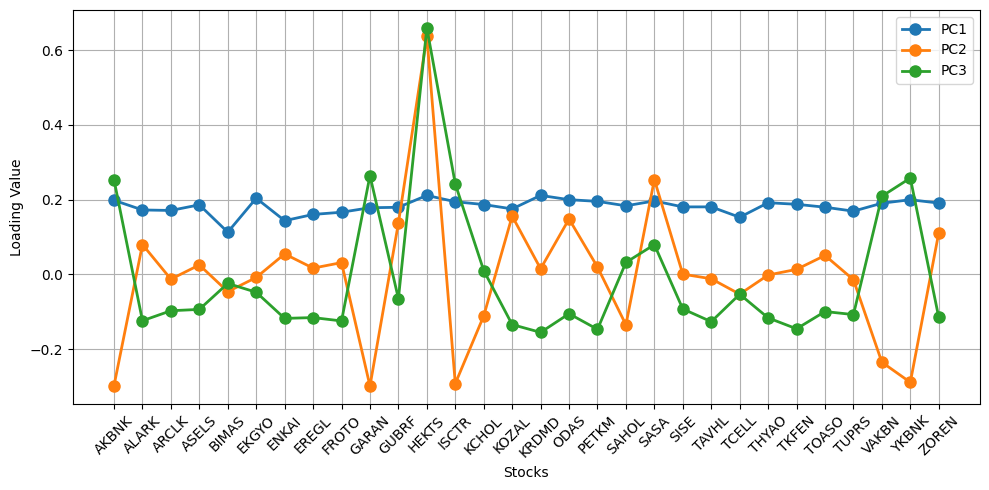

In [5]:
plot_pca2(log_data)

## Time-Varying Explained Variance

To analyze the stability of the factor structure, PCA is re-estimated
using a rolling 60-day window.

Key insights:
- The explanatory power of PC1 declines over time,
  indicating periods of reduced market-wide co-movement.
- Higher-order components gain importance during certain intervals,
  consistent with regime shifts or sectoral divergence.

This highlights that **correlation structures are not static**,
especially in emerging markets.

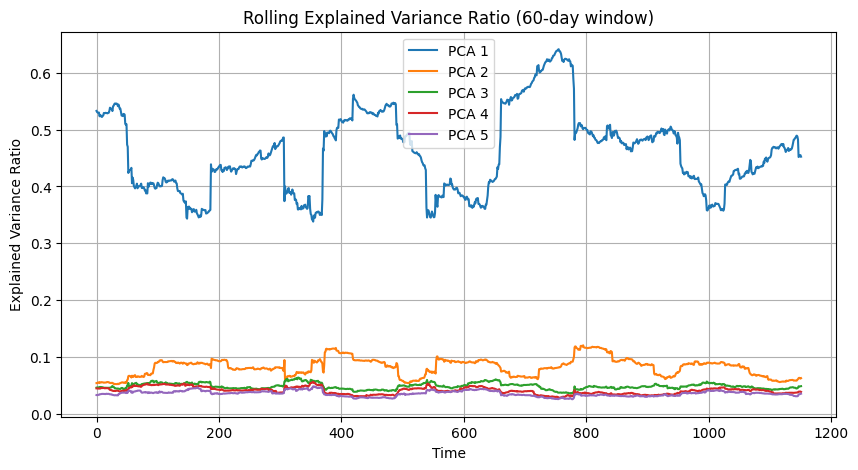

In [6]:
plot_pca3(log_data)

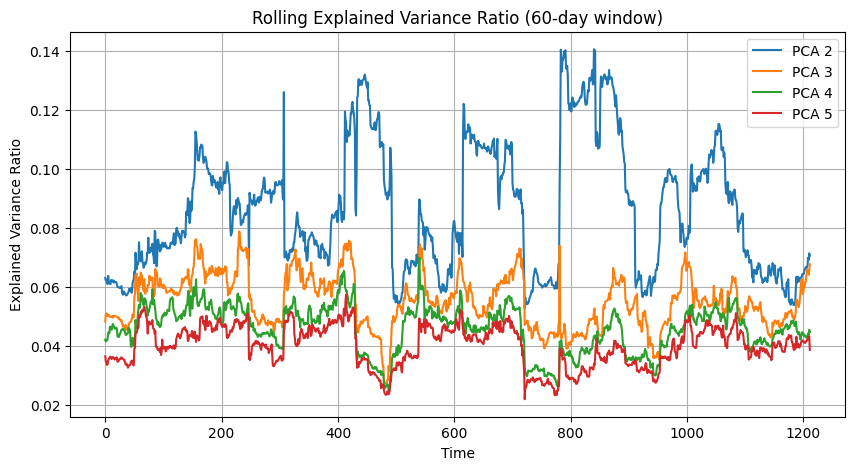

In [7]:
plot_pca4(log_data)

## Eigen-Portfolios vs BIST-30 Index

Using the PCA loadings, we construct eigen-portfolios by projecting
stock returns onto the principal components.

- PC1 is interpreted as a **market factor portfolio**.
- PC2 is treated as a **market-neutral factor**, capturing relative movements.

The comparison with the BIST-30 index shows that:
- PC1 closely tracks the index dynamics,
- PC2 exhibits lower correlation and smoother behavior.

This supports the interpretation of PC1 as a systematic risk factor.


/Users/mehmedekinelitog/Desktop/bist-correlation-pca/src/plotting.py:103: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bist30_price = yf.download("XU030.IS", start=data.index.min(), end=data.index.max(), progress=False)["Close"].dropna()


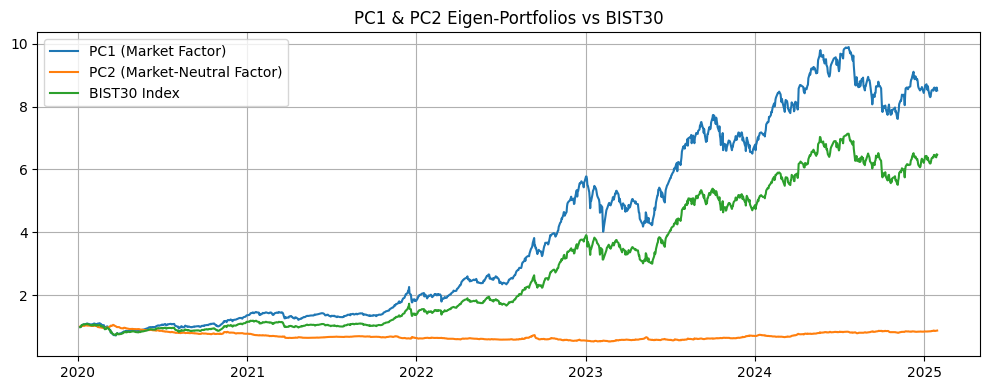

In [8]:
plot_pca5(log_data)

## Factor Validation via Regression Analysis

While PCA identifies statistical components, it does not assign
economic meaning by itself.

To validate whether the first principal component (PC1) represents
a market-wide factor, we perform regression-based tests.

If PC1 is a true market factor:
- It should strongly explain the BIST-30 index returns,
- It should account for a large fraction of individual stock returns.

This approach is conceptually similar to CAPM, where the market portfolio
is replaced by a data-driven factor extracted via PCA.

In [9]:
model = regression(log_data)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               XU030.IS   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                 1.284e+04
Date:                Wed, 21 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:02:52   Log-Likelihood:                 4714.8
No. Observations:                1255   AIC:                            -9426.
Df Residuals:                    1253   BIC:                            -9415.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.768e-05      0.000     -0.547      0.5

/Users/mehmedekinelitog/Desktop/bist-correlation-pca/src/analysis.py:28: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bist30_price = yf.download("XU030.IS", start=data.index.min(), end=data.index.max(), progress=False)["Close"].dropna()


## Conclusion

This analysis demonstrates that:
- BIST-30 returns are dominated by a strong common market factor,
- PCA effectively captures this structure with very few components,
- Factor importance varies over time, indicating regime dependence.

PCA provides a powerful framework for:
- Factor modeling,
- Portfolio construction,
- Market structure analysis in correlated equity markets.